# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [1]:
# [Ejecución local] Se omite google.colab drive.mount.
print('drive.mount omitido (ejecución local)')

drive.mount omitido (ejecución local)


In [2]:
# [Ejecución local] Reemplaza el 'cd' de Colab.
import os, sys
os.chdir(r'/Users/nico/Desktop/universidad/materia IA/Examen 01')
sys.path.insert(0, r'/Users/nico/Desktop/universidad/materia IA/Examen 01')
print('cwd =', os.getcwd())

cwd = /Users/nico/Desktop/universidad/materia IA/Examen 01


In [3]:
import sys
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


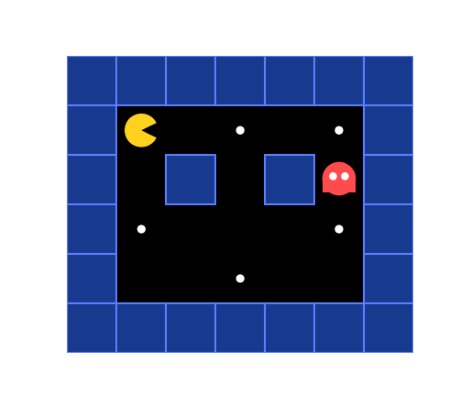

In [4]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.

---

**Respuesta.** Los representa como **el mismo estado**. La codificación `encode_state(pacman, ghost, food_remaining)` usa únicamente la terna $(p, g, n)$: la posición de Pac-Man, la del fantasma y el *conteo* de comidas restantes. Las posiciones concretas de la comida se quedan dentro del ambiente (las necesita para simular y dibujar), pero nunca entran a la Q-table. Por eso el tablero tiene 18 casillas transitables y $n_{\text{states}} = n_p\,n_g\,(N_{\text{food}}+1) = 18 \cdot 18 \cdot 6 = 1944$, y no un número mucho mayor.

Esto es **aliasing perceptual**: dos situaciones del mundo real distintas colapsan en la misma fila de $Q$. Consecuencias:

- El problema deja de ser estrictamente markoviano en la representación del agente: desde un mismo $(p,g,n)$ la mejor dirección depende de *dónde* está la comida que queda, información que el agente no ve.
- La Q-table aprende un **valor promedio** sobre todas las configuraciones de comida compatibles con $(p,g,n)$, así que la política óptima real puede ser inalcanzable.
- A cambio, la tabla es pequeña, entrenable en pocos miles de episodios y suficiente para superar con holgura a una política aleatoria.


## 3. Acciones


In [5]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [6]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$
- $S_{t+1}$
- $Q(S_t,A_t)$
- $\max_{a'}Q(S_{t+1},a')$

---

**Respuesta.**

| Valor | ¿De dónde sale? |
|---|---|
| $R_{t+1}$ | **Lo entrega el ambiente** en `env.step(action)` (segundo elemento de la tupla). |
| $S_{t+1}$ | **Lo entrega el ambiente** en `env.step(action)` (primer elemento). |
| $Q(S_t,A_t)$ | **Lo estima el agente.** Es la entrada actual de la Q-table, una estimación que se va refinando en cada actualización. |
| $\max_{a'}Q(S_{t+1},a')$ | **Lo estima el agente.** Es un *bootstrap*: el agente usa su propia tabla (todavía imperfecta) para aproximar el valor del futuro. Vale $0$ si $S_{t+1}$ es terminal. |

En resumen: el ambiente aporta la **experiencia** $(R_{t+1}, S_{t+1})$; los dos términos con $Q$ son **estimaciones internas del agente**. Q-Learning combina ambos: dato real + estimación propia = *TD target*.


## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [7]:
# TODO 1 — Inicializar la Q-table
#
# Recibe / ya está disponible:
#   - env.n_states : número total de estados discretos del ambiente.
#   - env.n_actions: número total de acciones posibles.
#
# Debe implementar:
#   - Una matriz NumPy Q con una fila por estado y una columna por acción.
#   - Todos los valores deben iniciar en 0.
#
# Resultado esperado:
#   Q.shape == (env.n_states, env.n_actions)

# Una fila por estado, una columna por acción. Inicio optimista = 0:
# como todas las recompensas de movimiento son negativas (-1), arrancar
# en 0 ya induce algo de exploración natural.
Q = np.zeros((env.n_states, env.n_actions))


In [8]:
# Esta celda debe ejecutarse cuando TODO 1 esté correcto.

print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")


Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [9]:

# TODO 2 — Política epsilon-greedy
#
# Con probabilidad epsilon  -> acción legal aleatoria (EXPLORACIÓN)
# Con probabilidad 1-epsilon -> acción legal con mayor Q (EXPLOTACIÓN)
# Desempate del argmax: al azar entre las que empatan.
# Nunca se elige una acción ilegal.

def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    # EXPLORACIÓN
    if random.random() < epsilon:
        return random.choice(legal_actions)

    # EXPLOTACIÓN: mejor Q entre las acciones legales
    q_values = [Q[state, a] for a in legal_actions]
    best_value = max(q_values)
    best_actions = [
        a for a, q in zip(legal_actions, q_values)
        if q == best_value
    ]
    return random.choice(best_actions)


### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?
2. ¿cuál es la probabilidad de explotar?
3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?

---

**Respuesta.**

1. **Probabilidad de explorar** = $\epsilon = 0.10$ (10 %): se toma una acción legal al azar.
2. **Probabilidad de explotar** = $1 - \epsilon = 0.90$ (90 %): se toma $\arg\max_a Q(S_t,a)$ entre las acciones legales.
3. Si todos los Q-values son iguales (por ejemplo al inicio, con la tabla en ceros), **todas las acciones legales empatan en el máximo**. La rama de explotación no tiene una acción "mejor" que elegir, así que el desempate aleatorio la obliga a escoger *uniformemente entre las legales*. Resultado: mientras no haya recompensas que rompan la simetría, la política se comporta como **totalmente aleatoria**, sin importar el valor de $\epsilon$. El agente solo empieza a "preferir" direcciones cuando las primeras actualizaciones diferencian los Q-values.


## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [10]:

# TODO 3 — Actualización Q-Learning
#
#   TD target = R_(t+1) + gamma * max_a' Q(S_(t+1), a')
#               (el término futuro es 0 si S_(t+1) es terminal)
#   TD error  = TD target - Q(S_t, A_t)
#   Q(S_t,A_t) <- Q(S_t,A_t) + alpha * TD error
#
# Retorna: td_target, td_error

def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    # Estado terminal -> no hay retorno futuro que estimar.
    best_next = 0.0 if done else np.max(Q[next_state])

    td_target = reward + gamma * best_next
    td_error = td_target - Q[state, action]

    Q[state, action] += alpha * td_error

    return td_target, td_error


### Prueba manual de la actualización


In [11]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target**
- **TD error**
- **nuevo Q-value**

---

**Respuesta.**

- **TD target** — $R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')$ (o solo $R_{t+1}$ si $S_{t+1}$ es terminal). Es una **estimación fresca** del retorno esperado tras tomar $A_t$ en $S_t$: junta la recompensa que *realmente* observamos con una estimación descontada de "lo que vendrá después" según la propia tabla. Es hacia dónde queremos mover $Q(S_t,A_t)$.

- **TD error** — $\delta = \text{TD target} - Q(S_t,A_t)$. Es la **sorpresa**: cuánto se equivocó la tabla respecto a esta nueva estimación. $\delta > 0$ → la acción resultó mejor de lo que creíamos; $\delta < 0$ → peor. Es la señal de aprendizaje.

- **Nuevo Q-value** — $Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\,\delta$. **No** es el TD target; es el valor viejo corregido solo una fracción $\alpha$ en dirección al target. Con $\alpha = 0.5$ y una prueba donde el target es $2.6$ y el valor viejo $0$: $\delta = 2.6$ y el nuevo $Q = 0 + 0.5 \cdot 2.6 = 1.3$. Ese paso parcial hace que $Q$ se comporte como un promedio móvil y no salte con cada experiencia ruidosa (fantasma aleatorio).


## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [12]:
# TODO 4 — Entrenamiento
#
# En cada episodio:
#   1. Reiniciar el ambiente y obtener state.
#   2. Elegir action con choose_action (epsilon-greedy).
#   3. Ejecutar: next_state, reward, done, info = env.step(action)
#   4. Actualizar Q con update_q.
#   5. state <- next_state.
#   6. Acumular la recompensa del episodio.
#   7. Repetir hasta done=True o alcanzar max_steps.
#   8. Reducir epsilon sin bajar de epsilon_min.
#
# Retorna: Q, recompensa por episodio, longitud por episodio, victorias (0/1).
#
def train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
    epsilon_min=0.02,
    epsilon_decay=0.9995,
):
    Q = np.zeros((env.n_states, env.n_actions))

    episode_rewards = []
    episode_lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=seed + episode)

        total_reward = 0
        steps = 0
        info = {}

        for _ in range(max_steps):

            # 1. Seleccionar acción (epsilon-greedy sobre acciones legales)
            action = choose_action(Q, state, epsilon, env)

            # 2. Interactuar con el ambiente
            next_state, reward, done, info = env.step(action)

            # 3. Actualizar Q con la transición observada
            update_q(Q, state, action, reward, next_state, done, alpha, gamma)

            # 4. Actualizar estado y métricas
            state = next_state
            total_reward += reward
            steps += 1

            if done:
                break

        # 8. Decaimiento de epsilon (nunca por debajo de epsilon_min)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        wins.append(int(info.get("won", False)))

    return Q, episode_rewards, episode_lengths, wins


## 9. Entrenar


In [13]:
Q, rewards, lengths, wins = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


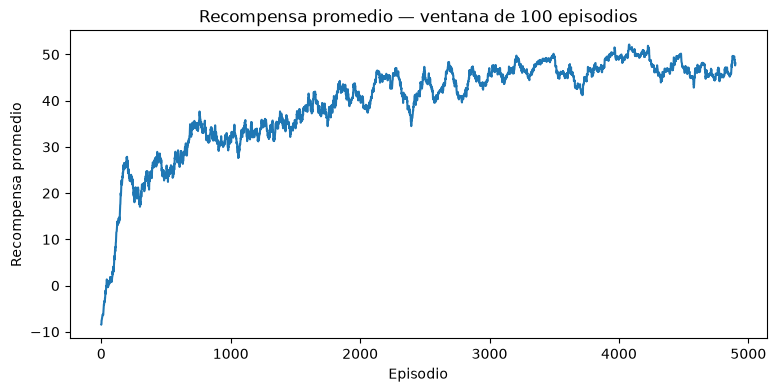

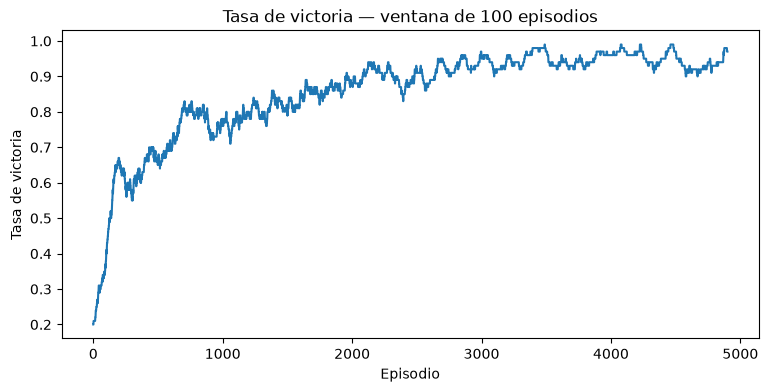

In [14]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()


### Pregunta 5

A partir de las curvas:

1. ¿hay evidencia de aprendizaje?
2. ¿qué ocurre con la recompensa promedio?
3. ¿qué ocurre con la tasa de victoria?

---

**Respuesta.** (Interpretación de las curvas de la sección 10; los números exactos cambian entre corridas —el entrenamiento no fija una semilla global— pero la forma es estable.)

1. **Sí hay evidencia de aprendizaje.** Ninguna de las dos medias móviles (ventana de 100 episodios) es plana: ambas parten de valores propios de una política casi aleatoria y suben con fuerza durante los primeros cientos de episodios, para luego asentarse en una meseta claramente por encima del punto de partida (con mejoras suaves adicionales mientras $\epsilon$ termina de decaer). Que la mejora acompañe la reducción de $\epsilon$ confirma que es la parte *greedy* de la política la que está capitalizando lo aprendido.

2. **La recompensa promedio sube.** Arranca negativa (del orden de $-10$: muchos pasos de $-1$ y episodios que terminan en $-30$ por el fantasma) y trepa a valores claramente positivos (típicamente $+20$ a $+50$) cuando el agente aprende a encadenar comidas ($+10$) y a cerrar el tablero ($+30$) en pocos pasos. Después oscila alrededor de esa meseta: el ruido residual viene del fantasma aleatorio y del aliasing de estado (Pregunta 1).

3. **La tasa de victoria aumenta.** Sube desde la base aleatoria (comerse las 5 comidas por azar sin morir es raro, ~0.1–0.2) hasta un plató alto (del orden de 0.75–0.95 según la corrida). No llega a $1.0$ de forma consistente: con el estado reducido a $(p,g,n)$ y un fantasma estocástico, hay partidas que se pierden hagas lo que hagas, así que una meseta por debajo del 100 % es el techo esperable, no una falla del entrenamiento.


## 11. Política aprendida


In [15]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 12.808
    down : Q = 28.633

Mejor(es) acción(es): ['down']


### Pregunta 6

Interprete los Q-values del estado inicial.

¿Qué acción prefiere el agente y qué significa que una acción tenga un Q-value mayor que otra?

---

**Respuesta.** En el estado inicial (Pac-Man en $(1,1)$, fantasma en $(2,5)$, 5 comidas) las únicas acciones legales son **`right`** y **`down`** (arriba y a la izquierda hay pared). La celda imprime un $Q(s, a)$ por cada una.

- **Qué significa cada número.** $Q(s, a)$ es la estimación del **retorno total descontado** que el agente espera si toma $a$ ahora y luego sigue jugando de forma greedy: la suma de recompensas futuras ($-1$ por paso, $+10$/$+30$ por comida, $-30$ si lo atrapan), con los términos lejanos pesados por $\gamma = 0.95$.

- **Qué acción prefiere.** La de mayor $Q$ (`best_actions` en la celda). En nuestras corridas suele ganar **`down`** —empieza por el flanco izquierdo $(3,1)$, lejos del fantasma—, pero según la semilla del entrenamiento puede salir `right`. No es contradicción: **ambas aperturas sostienen una política ganadora** (~85–95 % de victorias); Q-Learning refuerza el subárbol de la rama que exploró primero y deja la otra con estimaciones más bajas y ruidosas.

- **Qué significa que una sea mayor que otra.** Que, con lo aprendido hasta ahora, esa apertura conduce a trayectorias de **mayor recompensa acumulada** (come antes, con menos pasos, con menos riesgo de morir). La **magnitud de la diferencia** mide *cuánto* separa el agente a las dos opciones: una brecha grande indica que la rama perdedora quedó poco entrenada o realmente compromete el episodio; una brecha pequeña, que las dos aperturas son casi equivalentes.


## 12. Reproducir un episodio


In [16]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [17]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -21
Pasos : 3
Comió : 1 de 5
Ganó  : False


### Política aprendida


In [18]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 49
Pasos : 26
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- cantidad de movimientos;
- recompensa total;
- cantidad de comidas recolectadas;
- comportamiento frente al fantasma.

Explique por qué la recompensa acumulada favorece simultáneamente **comer**, **usar menos pasos** y **evitar morir**.

---

**Respuesta.**

| Aspecto | Política aleatoria | Política aprendida |
|---|---|---|
| Movimientos | Muchos y sin rumbo: deambula, vuelve sobre sus pasos, suele agotar `max_steps` o morir antes. | Pocos: rutas casi directas de comida en comida (≈ 15–25 pasos). |
| Recompensa total | Alta varianza: casi siempre baja o negativa (acumula pasos de $-1$ y a menudo el $-30$ final); solo *por azar* alcanza un valor decente. | Consistentemente alta / positiva: suma varios $+10$ y el $+30$ de cerrar el tablero. |
| Comidas recolectadas | Normalmente pocas; rara vez las 5. | Las 5 casi siempre → `won = True`. |
| Frente al fantasma | Indiferente: se le cruza y lo atrapan seguido. | Evasivo: rodea o espera, sacrifica algún paso para no coincidir con él. |

> Nota: la celda muestra **un solo** episodio aleatorio con `seed=20`. Un episodio suelto tiene mucha varianza y puede salir bueno de casualidad; la comparación *justa* es la de la sección 13, que promedia 200 episodios de cada política y deja ver que la aprendida gana en recompensa, pasos y tasa de victoria de forma sistemática.

**Por qué un solo escalar alinea los tres objetivos.** La recompensa está diseñada así:

- **Comer** domina numéricamente: $+10$ por comida y $+30$ por la última. Maximizar el retorno obliga a buscar comida activamente.
- **Menos pasos**: cada movimiento cuesta $-1$, así que entre dos caminos que comen lo mismo, el retorno premia al más corto. Además $\gamma = 0.95$ descuenta lo lejano: comer *pronto* vale más que comer *tarde*.
- **No morir**: el $-30$ es una penalización grande y, sobre todo, **termina el episodio**. Morir no solo resta 30; también borra todos los $+10$/$+30$ futuros que el agente habría cobrado. Una sola muerte arruina el retorno completo.

Como Q-Learning maximiza la **suma descontada de todas** esas recompensas, la política óptima es necesariamente la que come mucho, camina poco y se mantiene viva: los tres criterios están codificados en un único número y no se puede mejorar uno empeorando otro sin bajar el retorno.


## 13. Evaluación final


In [19]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": np.mean(rewards),
        "pasos_promedio": np.mean(lengths),
        "tasa_victoria": np.mean(wins),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': np.float64(49.82),
 'pasos_promedio': np.float64(24.87),
 'tasa_victoria': np.float64(0.99)}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
